In [63]:
from astropy.io import fits
from astropy.time import Time
from astropy.timeseries import LombScargle

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import pickle
import glob

from scipy.optimize import curve_fit
import scipy.stats as ss
from sklearn.decomposition import PCA

import re  # find pattern in string
from tqdm import tqdm  # progress bar
import logging  # to avoid printing too many warnings

import tools as t

In [48]:
# define the path of the directory where dace data is saved
path_data = '../data/dace_sun/Test/Jun2018/'
direc_stack = 'STACKED/'  # sub directory where the specific data is
direc_pre = 'PREPROCESSED/'
# load absorption bands
bands = np.genfromtxt('../data/bands.txt', dtype=None, encoding=None, names=True, delimiter=',')

In [49]:
# iterate over saved files in direc
# save names of the files
rassine_files = []
stacked_files = []
for entry in os.scandir(path_data + direc_stack):
    name = entry.name
    if name.endswith('.p'):
        if name.startswith('RASSINE'):
            rassine_files.append(name)
        else:
            stacked_files.append(name)

pre_files = []
for entry in os.scandir(path_data + direc_pre):
    pre_files.append(entry.name)

print(rassine_files)

['RASSINE_Stacked_spectrum_B1.00_D2018-06-22T19:23:29.961.p', 'RASSINE_Stacked_spectrum_B1.00_D2018-06-12T15:20:51.962.p', 'RASSINE_Stacked_spectrum_B1.00_D2018-06-05T23:28:30.043.p', 'RASSINE_Stacked_spectrum_B1.00_D2018-06-28T15:14:09.829.p', 'RASSINE_Stacked_spectrum_B1.00_D2018-06-18T00:03:47.954.p', 'RASSINE_Stacked_spectrum_B1.00_D2018-06-22T09:34:50.160.p', 'RASSINE_Stacked_spectrum_B1.00_D2018-06-14T18:01:08.359.p', 'RASSINE_Stacked_spectrum_B1.00_D2018-06-04T08:46:37.033.p', 'RASSINE_Stacked_spectrum_B1.00_D2018-06-08T02:24:03.023.p', 'RASSINE_Stacked_spectrum_B1.00_D2018-06-14T00:22:11.035.p', 'RASSINE_Stacked_spectrum_B1.00_D2018-06-02T13:18:22.174.p', 'RASSINE_Stacked_spectrum_B1.00_D2018-06-10T21:30:38.998.p', 'RASSINE_Stacked_spectrum_B1.00_D2018-06-11T21:18:44.469.p', 'RASSINE_Stacked_spectrum_B1.00_D2018-06-02T02:58:18.602.p', 'RASSINE_Stacked_spectrum_B1.00_D2018-06-30T13:45:37.518.p', 'RASSINE_Stacked_spectrum_B1.00_D2018-06-08T13:45:15.113.p', 'RASSINE_Stacked_spectr

In [67]:
path_ras = path_data + direc_stack + rassine_files[0]
data_ras = pickle.load(open(path_ras, "rb"))
print(data_ras.keys())
wl = data_ras['wave']
flux = data_ras['flux'] / data_ras['output']['continuum_linear']

dict_keys(['wave', 'flux', 'flux_err', 'flux_used', 'output', 'parameters', 'matching_anchors', 'matching_diff'])


In [51]:
path_stack = path_data + direc_stack + stacked_files[0]
data_stack = pickle.load(open(path_stack, "rb"))
print(data_stack.keys())
print(len(data_stack['arcfiles']))

dict_keys(['flux', 'flux_err', 'jdb', 'mjd', 'berv', 'lamp_offset', 'acc_sec', 'RV_shift', 'RV_sys', 'SNR_5500', 'hole_left', 'hole_right', 'wave_min', 'wave_max', 'dwave', 'stacking_length', 'nb_spectra_stacked', 'arcfiles'])
24


In [68]:
stacked_files[0], rassine_files[0]

('Stacked_spectrum_B1.00_D2018-06-14T18:01:08.359.p',
 'RASSINE_Stacked_spectrum_B1.00_D2018-06-22T19:23:29.961.p')

In [71]:
# save important data: data from rassine files + arcfiles from stacked files
data = {}
for stacked_name in stacked_files:  # iterate over stacked files
    for ras_name in rassine_files:  # iterate over rassine files
        if ras_name.endswith(stacked_name):  # names of the files coincide
            data_ras = pickle.load(open(path_data + direc_stack + ras_name, "rb"))  # load data
            data_stack = pickle.load(open(path_data + direc_stack + stacked_name, "rb"))  # load data
            data_ras['arcfiles'] = data_stack['arcfiles']  # add relevant data from stack to ras
            data[stacked_name] = data_ras  # save data
            break

In [87]:
ex = 'Stacked_spectrum_B1.00_D2018-06-14T18:01:08.359.p'
wl = data[ex]['wave']
cont = data[ex]['output']['continuum_linear']
pre_files = data[ex]['arcfiles']
n_files = len(pre_files)
flux = []
#wl_f = []
for f in pre_files:
    data_f = pickle.load(open(pre_files[0], "rb"))
    flux.append(data_f['flux'])
    #wl_f.append(np.arange(data_f['wave_min'], data_f['wave_max'], data_f['dwave']))  # seems to be the same as wl

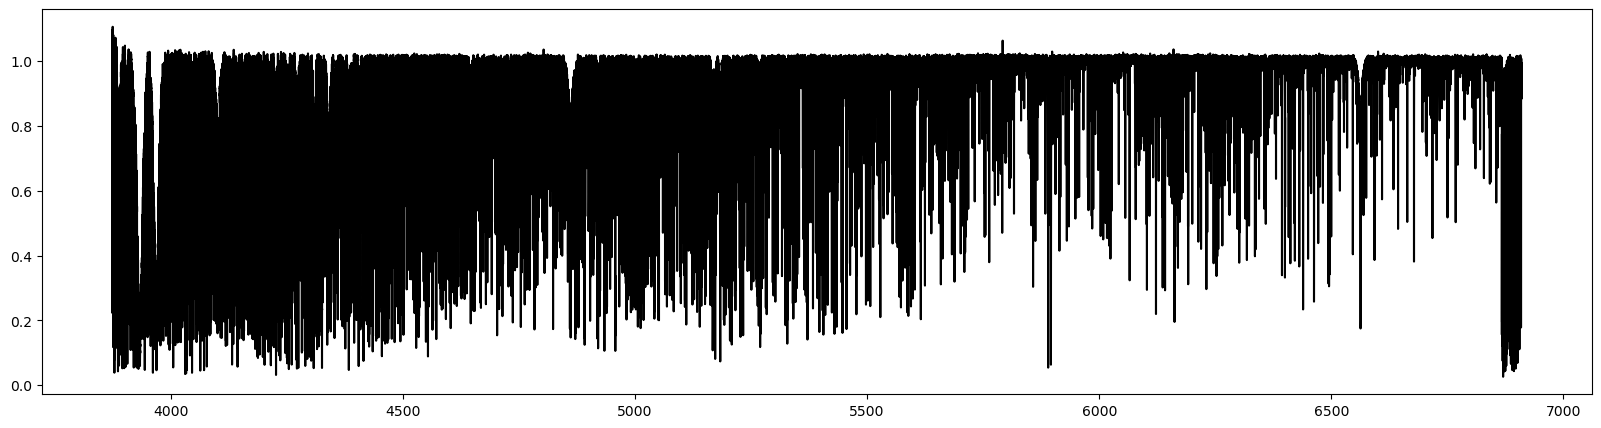

In [88]:
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(wl, flux[0] * n_files / cont, 'k')
plt.show()

In [61]:
with open(path_data + "MASTER/RASSINE_Master_spectrum_2026-06-03T13:05:18.p", "rb") as f:
    d = pickle.load(f)

print(d.keys())
print(d["output"].keys())
df = pd.read_csv(path_data + "matching_anchors.csv")

dict_keys(['wave', 'flux', 'flux_err', 'flux_used', 'output', 'parameters', 'matching_anchors'])
dict_keys(['continuum_linear', 'anchor_wave', 'anchor_flux', 'anchor_index'])


In [62]:
df.shape

(31, 6)

In [54]:
with open(path_data + direc_pre + pre_files[0], "rb") as f:
    d = pickle.load(f)

print(d.keys())

dict_keys(['flux', 'flux_err', 'RV_sys', 'RV_shift', 'SNR_5500', 'berv', 'lamp_offset', 'plx_mas', 'acc_sec', 'instrument', 'mjd', 'jdb', 'hole_left', 'hole_right', 'wave_min', 'wave_max', 'dwave'])


## Prepare data for RASSINE

In [71]:
# define the path of the directory where dace data is saved
path_data = '../data/dace_sun/Test/Jun2018/'
path_raw = 'RAW/'  # sub directory where the specific data is
# load absorption bands
bands = np.genfromtxt('../data/bands.txt', dtype=None, encoding=None, names=True, delimiter=',')

In [72]:
# iterate over raw files
# save names of the files
files = []
for entry in os.scandir(path_data + path_raw):
    files.append(entry.name)

print(files)

['r.HARPN.2018-06-15T16-20-07.065_S1D_A.fits', 'r.HARPN.2018-06-25T09-31-50.163_S1D_A.fits', 'r.HARPN.2018-06-22T13-00-24.749_S1D_A.fits', 'r.HARPN.2018-06-20T13-23-18.988_S1D_A.fits', 'r.HARPN.2018-06-15T15-09-32.416_S1D_A.fits', 'r.HARPN.2018-06-26T11-16-38.588_S1D_A.fits', 'r.HARPN.2018-06-22T11-33-28.296_S1D_A.fits', 'r.HARPN.2018-06-05T13-38-00.052_S1D_A.fits', 'r.HARPN.2018-06-18T10-29-53.905_S1D_A.fits', 'r.HARPN.2018-06-19T13-22-09.633_S1D_A.fits', 'r.HARPN.2018-06-19T14-38-12.819_S1D_A.fits', 'r.HARPN.2018-06-27T14-26-36.343_S1D_A.fits', 'r.HARPN.2018-06-21T09-27-17.959_S1D_A.fits', 'r.HARPN.2018-06-23T11-14-54.346_S1D_A.fits', 'r.HARPN.2018-06-25T09-42-44.646_S1D_A.fits', 'r.HARPN.2018-06-22T09-55-34.603_S1D_A.fits', 'r.HARPN.2018-06-08T09-46-21.583_S1D_A.fits', 'r.HARPN.2018-06-22T09-22-53.914_S1D_A.fits', 'r.HARPN.2018-06-04T12-20-31.715_S1D_A.fits', 'r.HARPN.2018-06-10T15-06-40.435_S1D_A.fits', 'r.HARPN.2018-06-11T15-14-05.466_S1D_A.fits', 'r.HARPN.2018-06-05T12-48-58.194_

In [91]:
path_dace = '../data/dace_sun/'
direc = 'Jun2018/'

In [92]:
# iterate over saved files in direc
# save names (observation dates) of the files
dates_files = []
for entry in os.scandir(path_dace + direc):
    if entry.name != 'spectra.txt' and entry.name != 'CCF':
        dates_files.append(entry.name)

dates_files = sorted(dates_files, key=lambda d: datetime.strptime(d, "%Y-%m-%d"))  # sort
print(dates_files)

['2018-06-01', '2018-06-02', '2018-06-03', '2018-06-04', '2018-06-05', '2018-06-06', '2018-06-07', '2018-06-08', '2018-06-09', '2018-06-10', '2018-06-11', '2018-06-12', '2018-06-13', '2018-06-14', '2018-06-15', '2018-06-16', '2018-06-17', '2018-06-18', '2018-06-19', '2018-06-20', '2018-06-21', '2018-06-22', '2018-06-23', '2018-06-24', '2018-06-25', '2018-06-26', '2018-06-27', '2018-06-28', '2018-06-29', '2018-06-30']


In [93]:
# make a list of the available files that end by A.fits (s1d)
files_list = []
for d in dates_files:  # iterate over directories
    date_path = path_dace + direc + d + '/'
    files = os.scandir(date_path)  # files in directory
    files = list(files)
    files = [d + '/' + i.name for i in files]  # list of file names
    files_list.extend(files)  # save file names
files_list = [s for s in files_list if s.endswith('A.fits')]  # keep only the files that end by A.fits
files_list = np.array(files_list)
print(f's1d files: {len(files_list)}')

# make a list of the available files that end by A.fits (CCF)
files_ccf_list = []
for d in dates_files:  # iterate over directories
    date_path = path_dace + direc + 'CCF/' + d + '/'
    files = os.scandir(date_path)  # files in directory
    files = list(files)
    files = [d + '/' + i.name for i in files]  # list of file names
    files_ccf_list.extend(files)  # save file names
#files_ccf_list = [s for s in files_ccf_list if s.endswith('A.fits')]  # keep only the files that end by A.fits
files_ccf_list = np.array(files_ccf_list)
print(f'ccf files: {len(files_ccf_list)}')

s1d files: 703
ccf files: 703


In [94]:
# keep only ccf files that have a corresponding s1d file
files_s1d = []
files_ccf = []

for i in files_ccf_list:
    s1d_file = i.replace('CCF', 'S1D')
    if s1d_file in files_list:
        files_s1d.append(s1d_file)
        files_ccf.append(i)

files_s1d = np.array(files_s1d)
files_ccf = np.array(files_ccf)
print(len(files_ccf), len(files_s1d))

602 602


In [125]:
# extract data from s1d files
# save spectra in matrix rows
# the row i from spectra contains the spectrum from the file i from files_s1d
mjd = []
fnames = []
models = []
for f in files_s1d:  # iterate over files
    path_file = path_dace + direc + f
    hdul = fits.open(path_file)  # open file
    data = hdul[0].header
    mjd.append(data['MJD-OBS'])
    fnames.append('r.' + data['FILENAME'])
    models.append(data['HIERARCH TNG TEL TARG RADVEL'])

mjd = np.array(mjd)
fnames = np.char.replace(fnames, '.fits', '_S1D_A.fits')
models = np.array(models)

# extract data from ccf files
vrad = []
svrad = []
drift = []
for f in files_ccf:
    path_file = path_dace + direc + 'CCF/' + f
    hdul = fits.open(path_file)
    hdr0 = hdul[0].header
    vrad.append(hdr0['HIERARCH TNG QC CCF RV'])
    svrad.append(hdr0['HIERARCH TNG QC CCF RV ERROR'])
    drift.append(0)

vrad = np.array(vrad)
svrad = np.array(svrad)
drift = np.array(drift)